# UpSet plots & intersections

## Notebook Workflow

1. Load significant gene-ID lists from each analysis branch.
2. Build set intersections and UpSet visualizations.
3. Optionally intersect with silk-gland-associated gene sets.
4. Save publication-ready figures to `figures/`.

In [2]:
import os
import sys
import pip
import warnings
!{sys.executable} -m pip install openpyxl
!pip install --quiet upsetplot
from upsetplot import UpSet, from_contents
import matplotlib.pyplot as plt
import pandas as pd

# Make src importable whether cwd is repo root or scripts/
cwd = os.getcwd()
if os.path.basename(cwd) == "scripts":
    repo_root = os.path.abspath(os.path.join(cwd, ".."))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Using src path: {src_path}")

# Import the modules from src/
from hyphy_results_parser import (
    RelaxResult,
    BustedPhResult
)
from odds_ratio_test import PermutationTestResults
from id_converter import convert_hogs_to_locs, convert_locs_to_hogs

import get_silk_genes as silk

# Define paths to data and results directories
data = os.path.join(repo_root, "data")
figures = os.path.join(repo_root, "figures")
assets = os.path.join(repo_root, "assets")
results = os.path.join(repo_root, "results")

# Suppress FutureWarnings and SyntaxWarnings from libraries (especially upsetplot)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=SyntaxWarning)

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src


/Users/calvin/miniforge3/envs/orb-selection/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Read all the hit lists into a dictionary (as HOGs)

In [3]:
hits_lists = {}

### Silk gland genes & spidroins

In [4]:
silk_genes_list = silk.get_all_silk_genes(top10=False)
spidroins_list = pd.read_csv(f'{data}/spidroins_LOCs.tsv', sep='\t', dtype=str)['LOC'].tolist()

# There may end up being LOCs in these HOGs that are not in my silk gland gene list
# or spidroin list. However, if they are orthologous to those LOCs, they are still relevant.
silk_hogs = convert_locs_to_hogs(silk_genes_list, f'{data}/N5.tsv')
spidroin_hogs = convert_locs_to_hogs(spidroins_list, f'{data}/N5.tsv')

# These lists of HOGs are longer than the original lists of LOCs, meaning some LOCs 
# belong to multiple HOGs. This may be because multiple isoforms of the gene were 
# included in the original Orthofinder analysis.
hits_lists['silk_genes'] = list(set(silk_hogs['HOG'].tolist()))
hits_lists['spidroins'] = list(set(spidroin_hogs['HOG'].tolist()))

### Hyphy results

In [5]:
hyphy_results = results + "/hyphy_results_cache/"

# Load the saved RELAX results
relax_result = RelaxResult.load_from_pickle(str(hyphy_results + "relax_results.pkl"))
relax_result_fltrd = relax_result.filter_omega(10000)
relax_df_fltrd = relax_result_fltrd.results_df
hits_lists['relaxed_in_nonorb'] = list(relax_df_fltrd[relax_df_fltrd['result']=='relaxed'].index)
hits_lists['intensified_in_nonorb'] = list(relax_df_fltrd[relax_df_fltrd['result']=='intensified'].index)

# Load the saved BUSTED-PH results
busted_ph_result = BustedPhResult.load_from_pickle(str(hyphy_results + "busted_ph_results.pkl"))
busted_ph_result_fltrd = busted_ph_result.filter_omega(10000)
busted_ph_df_fltrd = busted_ph_result_fltrd.results_df
hits_lists['positive_sel_in_orb'] = list(busted_ph_df_fltrd[busted_ph_df_fltrd['result']=='hit'].index)

# Load the saved BUSTED-PH-REV results
busted_ph_rev_result = BustedPhResult.load_from_pickle(str(hyphy_results + "busted_ph_rev_results.pkl"))


busted_ph_rev_result_fltrd = busted_ph_rev_result.filter_omega(10000)
busted_ph_rev_df_fltrd = busted_ph_rev_result_fltrd.results_df
hits_lists['positive_sel_in_nonorb'] = list(busted_ph_rev_df_fltrd[busted_ph_rev_df_fltrd['result']=='hit'].index)

### Odds ratio test results

In [6]:
ort_dir = results + "/odds_ratio_test/Results_Mar25"

# Loss results
loss_results = PermutationTestResults.load_from_pickle(f'{ort_dir}/Run1_Loss_LT_50-95_10000x/loss_occ50-95_less.pkl')
loss_df = loss_results.results_fltrd_df

# Duplication results
dup_results = PermutationTestResults.load_from_pickle(f'{ort_dir}/Run2_Dup_RT_50-max_10000x/duplication_occ50-98_greater.pkl')
dup_df = dup_results.results_fltrd_df

Break down into HOGs that were more likely to be missing or in multiple copies in orbweavers or in non-orbweavers

In [7]:
hits_lists['duplication_more_likely_orb'] = list(dup_df[dup_df["Log odds ratio"] > 0].index)
hits_lists['duplication_more_likely_nonorb'] = list(dup_df[dup_df["Log odds ratio"] < 0].index)
hits_lists['loss_more_likely_orb'] = list(loss_df[loss_df["Log odds ratio"] > 0].index)
hits_lists['loss_more_likely_nonorb'] = list(loss_df[loss_df["Log odds ratio"] < 0].index)

## UpSet plot of Hyphy results only

In [8]:
hyphy_upset_dict = {
    'Positive selection ~ $\it{non}$-orbweaving': hits_lists['positive_sel_in_nonorb'],
    'Positive selection ~ orbweaving': hits_lists['positive_sel_in_orb'],
    'Selection $\it{intensified}$ in non-orbweavers': hits_lists['intensified_in_nonorb'],
    'Selection $\it{relaxed}$ in non-orbweavers': hits_lists['relaxed_in_nonorb'],
}

upset_data = from_contents(hyphy_upset_dict)

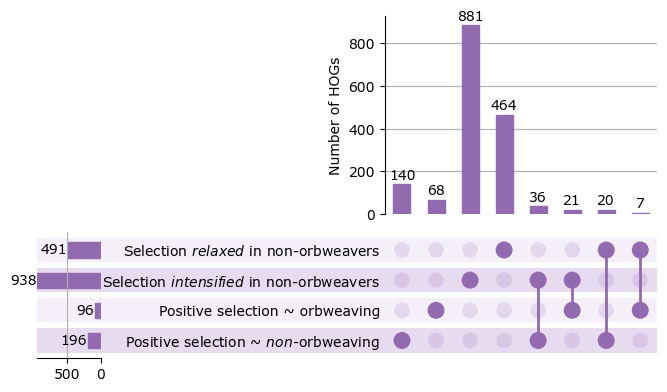

In [34]:
upset = UpSet(
    upset_data, show_counts=True, sort_categories_by=None, facecolor='#926AB0'
)

# upset.style_categories('Selection $\it{relaxed}$ in non-orbweavers', bar_facecolor='#FA8072', shading_facecolor='#FEE9E7')
# upset.style_categories('Positive selection ~ orbweaving', bar_facecolor='#4682B4', shading_facecolor='#E0EAF2')
# upset.style_categories('Positive selection ~ $\it{non}$-orbweaving', bar_facecolor='#DAA520', shading_facecolor='#F9F0D9')
# upset.style_categories('Selection $\it{intensified}$ in non-orbweavers', bar_facecolor='#639B51', shading_facecolor='#E0F2DB')

upset.style_categories('Selection $\it{relaxed}$ in non-orbweavers', bar_facecolor='#926AB0', shading_facecolor="#F5EFF9")
upset.style_categories('Selection $\it{intensified}$ in non-orbweavers', bar_facecolor='#926AB0', shading_facecolor='#E7DBF0')
upset.style_categories('Positive selection ~ orbweaving', bar_facecolor='#926AB0', shading_facecolor='#F5EFF9')
upset.style_categories('Positive selection ~ $\it{non}$-orbweaving', bar_facecolor='#926AB0', shading_facecolor='#E7DBF0')

# upset.style_subsets(present=['Selection $\it{relaxed}$ in non-orbweavers'], 
#                     absent=['Positive selection ~ orbweaving', 'Positive selection ~ $\it{non}$-orbweaving', 'Selection $\it{intensified}$ in non-orbweavers'],
#                     facecolor='#70547E')
# upset.style_subsets(present=['Positive selection ~ orbweaving'], 
#                     absent=['Selection $\it{relaxed}$ in non-orbweavers', 'Positive selection ~ $\it{non}$-orbweaving', 
#                             'Selection $\it{intensified}$ in non-orbweavers'],
#                     facecolor='#A579C6')
# upset.style_subsets(present=['Selection $\it{intensified}$ in non-orbweavers'], 
#                     absent=['Selection $\it{relaxed}$ in non-orbweavers', 'Positive selection ~ orbweaving', 'Positive selection ~ $\it{non}$-orbweaving'],
#                     facecolor='#A579C6')
# upset.style_subsets(present=['Positive selection ~ $\it{non}$-orbweaving'], 
#                     absent=['Selection $\it{relaxed}$ in non-orbweavers', 'Positive selection ~ orbweaving', 'Selection $\it{intensified}$ in non-orbweavers'],
#                     facecolor='#A579C6')

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'
plt.savefig(str(figures + '/figure_2/hyphy_upset.png'), dpi=300, transparent=False, bbox_inches='tight')

## UpSet plot of Hyphy results + silk genes/spidroins

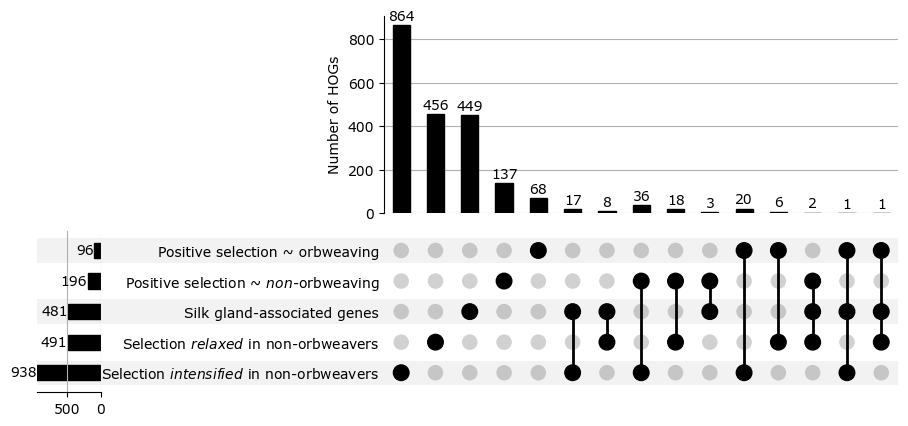

In [24]:
upset_dict_with_silk = hyphy_upset_dict.copy()
upset_dict_with_silk['Silk gland-associated genes'] = hits_lists['silk_genes']
# upset_dict_with_silk['Spidroins'] = hits_lists['spidroins']

upset_data_with_silk = from_contents(upset_dict_with_silk)

upset = UpSet(
    upset_data_with_silk, show_counts=True,
)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'

# Odds ratio test upset

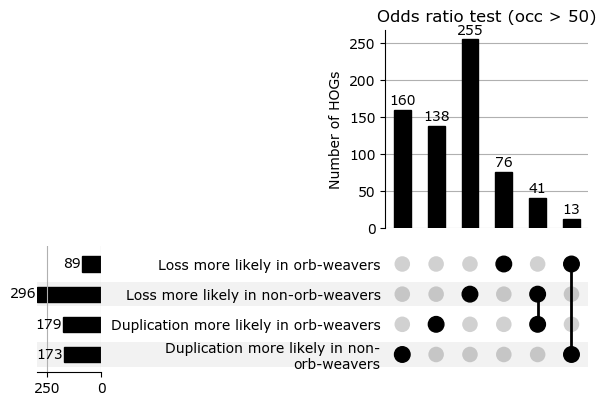

In [25]:
upset_dict_with_ort = {}

upset_dict_with_ort['Duplication more likely in non-\norb-weavers'] = hits_lists['duplication_more_likely_nonorb']
upset_dict_with_ort['Duplication more likely in orb-weavers'] = hits_lists['duplication_more_likely_orb']
upset_dict_with_ort['Loss more likely in non-orb-weavers'] = hits_lists['loss_more_likely_nonorb']
upset_dict_with_ort['Loss more likely in orb-weavers'] = hits_lists['loss_more_likely_orb']


upset_data_with_ort = from_contents(upset_dict_with_ort)

upset = UpSet(
    upset_data_with_ort, show_counts=True, sort_categories_by=None
)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'
plt.title('Odds ratio test (occ > 50)')

plt.savefig(str(figures + '/figure_5/ort_upset.png'), dpi=300, transparent=False, bbox_inches='tight')

## Odds ratio test upset with silk genes/spidroins

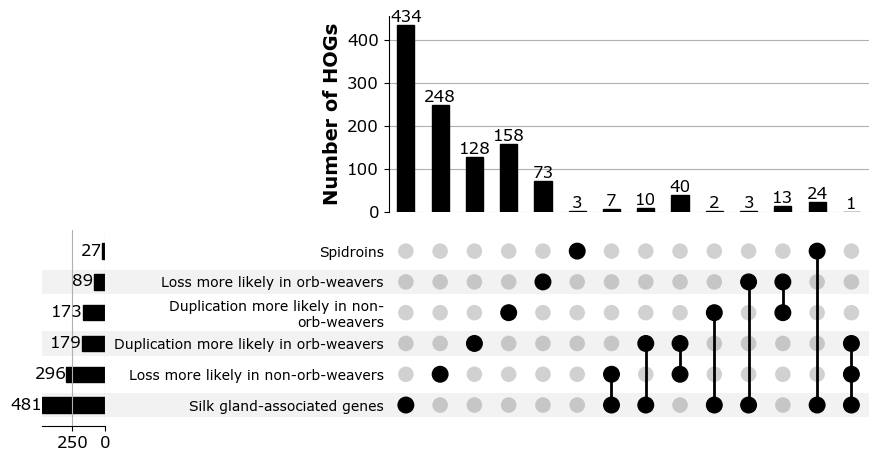

In [26]:
upset_dict_with_silk_ort = upset_dict_with_ort.copy()
upset_dict_with_silk_ort['Silk gland-associated genes'] = hits_lists['silk_genes']
upset_dict_with_silk_ort['Spidroins'] = hits_lists['spidroins']

upset_data_with_silk_ort = from_contents(upset_dict_with_silk_ort)

upset = UpSet(
    upset_data_with_silk_ort, show_counts=False,
)

upset.plot()
plt.ylabel('Number of HOGs', fontsize=14, fontweight='bold')
plt.rcParams['font.family'] = 'Verdana'
plt.tick_params(axis='y', labelsize=12)

for ax in plt.gcf().axes:
    for bar in ax.containers:
        ax.bar_label(bar, fontsize=12)  # Bar numerical labels top
    if hasattr(ax, 'get_xticklabels'):
        plt.setp(ax.get_xticklabels(), fontsize=12) # Bar numerical labels bottom

# plt.savefig(str(figures + '/figure_5/ort_silk_upset_plot.png'), dpi=300, transparent=False, bbox_inches='tight')


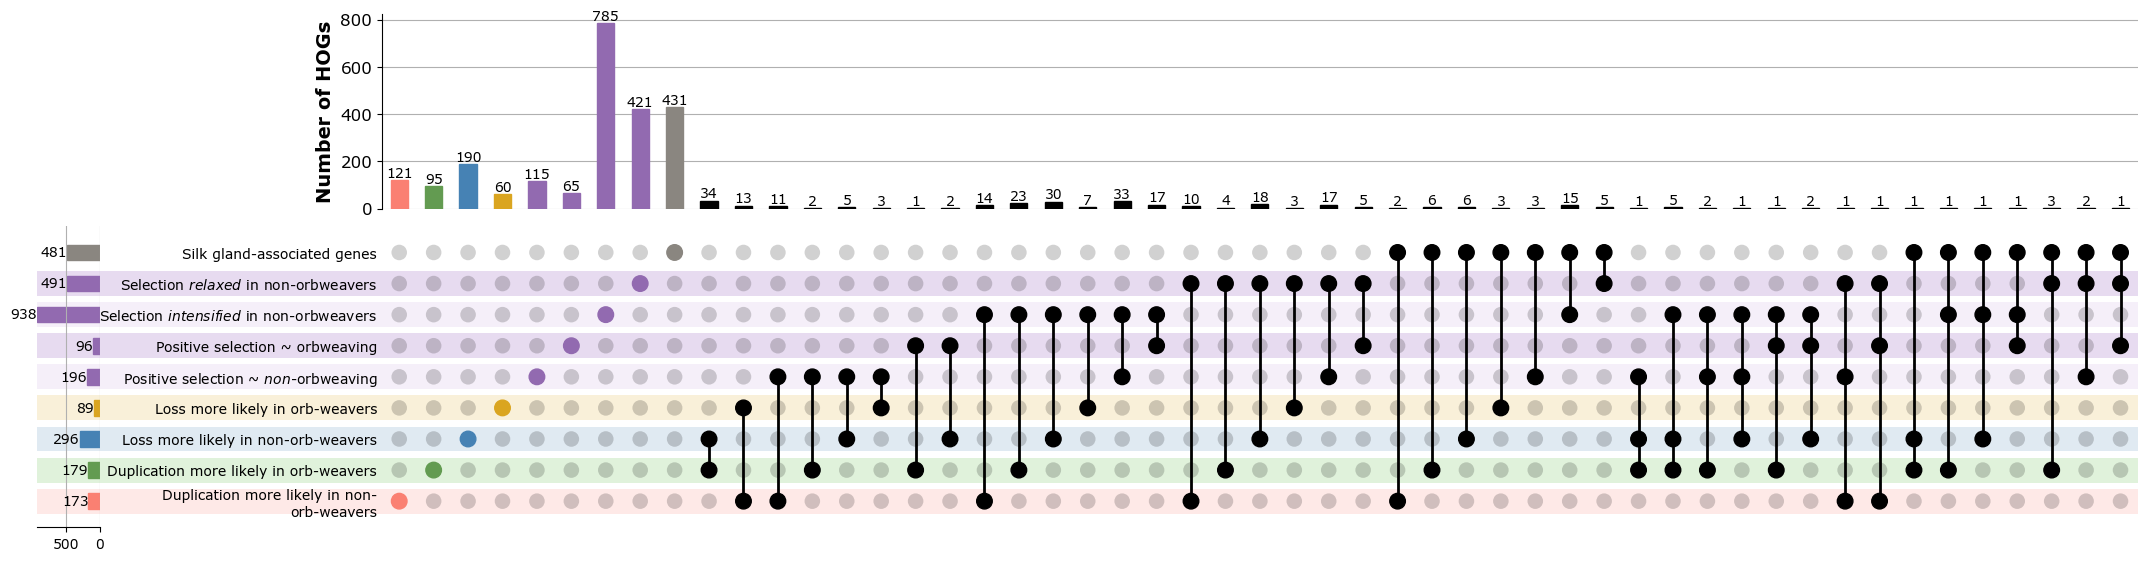

In [36]:
upset_dict_massive = upset_dict_with_ort | upset_dict_with_silk
# upset_dict_massive_50 = dict(reversed(list(upset_dict_massive_50.items())))
upset_dict_massive['Silk gland-associated genes'] = hits_lists['silk_genes']


upset_data_massive = from_contents(upset_dict_massive)

upset = UpSet(
    upset_data_massive,
    sort_categories_by=None
)

upset.style_categories('Selection $\it{relaxed}$ in non-orbweavers', bar_facecolor='#926AB0', shading_facecolor="#E7DBF0")
upset.style_categories('Selection $\it{intensified}$ in non-orbweavers', bar_facecolor='#926AB0', shading_facecolor='#F5EFF9')
upset.style_categories('Positive selection ~ orbweaving', bar_facecolor='#926AB0', shading_facecolor="#E7DBF0")
upset.style_categories('Positive selection ~ $\it{non}$-orbweaving', bar_facecolor='#926AB0', shading_facecolor="#F5EFF9")
# upset.style_categories('Selection $\it{relaxed}$ in non-orbweavers', bar_facecolor='#FA8072', shading_facecolor='#FEE9E7')
# upset.style_categories('Positive selection ~ orbweaving', bar_facecolor='#4682B4', shading_facecolor='#E0EAF2')
# upset.style_categories('Positive selection ~ $\it{non}$-orbweaving', bar_facecolor='#DAA520', shading_facecolor='#F9F0D9')
# upset.style_categories('Selection $\it{intensified}$ in non-orbweavers', bar_facecolor='#639B51', shading_facecolor='#E0F2DB')

upset.style_subsets(present=['Selection $\it{relaxed}$ in non-orbweavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Selection $\it{relaxed}$ in non-orbweavers'}),
                    facecolor="#926AB0")
upset.style_subsets(present=['Positive selection ~ orbweaving'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Positive selection ~ orbweaving'}),
                    facecolor="#926AB0")
upset.style_subsets(present=['Selection $\it{intensified}$ in non-orbweavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Selection $\it{intensified}$ in non-orbweavers'}),
                    facecolor="#926AB0")
upset.style_subsets(present=['Positive selection ~ $\it{non}$-orbweaving'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Positive selection ~ $\it{non}$-orbweaving'}),
                    facecolor="#926AB0")

upset.style_categories('Duplication more likely in non-\norb-weavers', bar_facecolor='#FA8072', shading_facecolor='#FEE9E7')
upset.style_categories('Loss more likely in non-orb-weavers', bar_facecolor='#4682B4', shading_facecolor='#E0EAF2')
upset.style_categories('Loss more likely in orb-weavers', bar_facecolor='#DAA520', shading_facecolor='#F9F0D9')
upset.style_categories('Duplication more likely in orb-weavers', bar_facecolor='#639B51', shading_facecolor='#E0F2DB')
upset.style_categories('Silk gland-associated genes', bar_facecolor='#8a8680', shading_facecolor='#FFFFFF')
# upset.style_categories('Spidroins', bar_facecolor='#8a8680', shading_facecolor='#E8DCF0')


upset.style_subsets(present=['Duplication more likely in non-\norb-weavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Duplication more likely in non-\norb-weavers'}),
                    facecolor='#FA8072')
upset.style_subsets(present=['Loss more likely in non-orb-weavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Loss more likely in non-orb-weavers'}),
                    facecolor='#4682B4')
upset.style_subsets(present=['Duplication more likely in orb-weavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Duplication more likely in orb-weavers'}),
                    facecolor='#639B51')
upset.style_subsets(present=['Loss more likely in orb-weavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Loss more likely in orb-weavers'}),
                    facecolor='#DAA520')
upset.style_subsets(present=['Silk gland-associated genes'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Silk gland-associated genes'}),
                    facecolor='#8a8680')
# upset.style_subsets(present=['Spidroins'], 
#                     absent=list(set(upset_dict_massive.keys()) - {'Spidroins'}),
#                     facecolor='#8a8680')

upset.plot()
plt.ylabel('Number of HOGs', fontsize=14, fontweight='bold')
plt.rcParams['font.family'] = 'Verdana'
plt.tick_params(axis='y', labelsize=12)

for ax in plt.gcf().axes:
    for bar in ax.containers:
        ax.bar_label(bar, fontsize=10)  # Bar numerical labels top
    if hasattr(ax, 'get_xticklabels'):
        plt.setp(ax.get_xticklabels(), fontsize=10) # Bar numerical labels bottom
plt.savefig(str(figures + '/figure_6/massive_upset_plot.png'), dpi=300, transparent=False, bbox_inches='tight')

In [87]:
upset_dict_massive.keys() - {'Duplication more likely in non-orb-weavers'}

{'Duplication more likely in non-\norb-weavers',
 'Duplication more likely in orb-weavers',
 'Loss more likely in non-orb-weavers',
 'Loss more likely in orb-weavers',
 'Positive selection ~ $\\it{non}$-orbweaving',
 'Positive selection ~ orbweaving',
 'Selection $\\it{intensified}$ in non-orbweavers',
 'Selection $\\it{relaxed}$ in non-orbweavers',
 'Silk gland-associated genes'}

In [88]:
def get_intersections(upset_dict, exclude=True):

    import itertools

    # Get all set names
    set_names = list(upset_dict.keys())

    # Convert lists to sets for set operations
    sets = {k: set(v) for k, v in upset_dict.items()}

    intersections = []

    # For all intersections (size 2 and up)
    for r in range(1, len(set_names) + 1):
        for combo in itertools.combinations(set_names, r):
            # Intersection of the selected sets
            intersect = sets[combo[0]].copy()
            for name in combo[1:]:
                intersect &= sets[name]
            if exclude:
                # Exclude elements present in any other set not in the combo (UpSet logic)
                other_sets = set(set_names) - set(combo)
                for name in other_sets:
                    intersect -= sets[name]
            if intersect:
                intersections.append((combo, sorted(intersect)))

    # Sort by decreasing length of intersection
    intersections.sort(key=lambda x: len(x[1]), reverse=True)

    # Remove intersections where the combo contains only one set
    intersections = [item for item in intersections if len(item[0]) > 1]

    # intersections now contains tuples: (combo, [elements]), sorted by size
    intersections_df = pd.DataFrame([
        {"Sets": ", ".join(combo), "Num_HOGs": len(hogs), "HOGs": ", ".join(hogs)}
        for combo, hogs in intersections
    ])

    intersections_df['HOGs'] = intersections_df['HOGs'].apply(lambda x: x.split(", ") if pd.notnull(x) else [])

    return intersections_df

In [89]:
intersections = get_intersections(hits_lists)

In [90]:
intersections_expanded = intersections.explode('HOGs').set_index('HOGs', drop=True)[['Sets']]
intersections_expanded

,Sets
HOGs,
N5.HOG0007812,"duplication_more_likely_orb, loss_more_likely_..."
N5.HOG0015441,"duplication_more_likely_orb, loss_more_likely_..."
N5.HOG0015835,"duplication_more_likely_orb, loss_more_likely_..."
N5.HOG0018884,"duplication_more_likely_orb, loss_more_likely_..."
N5.HOG0021150,"duplication_more_likely_orb, loss_more_likely_..."
...,...
N5.HOG0067416,"relaxed_in_nonorb, positive_sel_in_orb, duplic..."
N5.HOG0066569,"relaxed_in_nonorb, positive_sel_in_nonorb, dup..."
N5.HOG0059005,"intensified_in_nonorb, positive_sel_in_orb, du..."


In [91]:
intersections_locs = convert_hogs_to_locs(intersections_expanded, f'{data}/N5.tsv')

Processing HOGs: 100%|██████████| 340/340 [00:00<00:00, 571.71it/s]


In [92]:
intersections_list_fltrd = intersections_locs[['HOGs', 'Sets', 'LOC', 'GO_terms', 'Description']].drop_duplicates().reset_index(drop=True)
intersections_list_fltrd.rename(columns={'LOC': 'U_diversus_LOC'}, inplace=True)
intersections_list_fltrd.to_excel(f'{results}/Supplementary_Table_6_Hit_Intersections.xlsx', index=False)
intersections_list_fltrd

,HOGs,Sets,U_diversus_LOC,GO_terms,Description
0,N5.HOG0007812,"duplication_more_likely_orb, loss_more_likely_...",129223377,-,pantetheinase-like
1,N5.HOG0015441,"duplication_more_likely_orb, loss_more_likely_...",129221006,GO:0006511 [Name: ubiquitin-dependent protein ...,E3 ubiquitin-protein ligase RLIM-like
2,N5.HOG0015441,"duplication_more_likely_orb, loss_more_likely_...",NaN,NaN,NaN
3,N5.HOG0015835,"duplication_more_likely_orb, loss_more_likely_...",NaN,NaN,NaN
4,N5.HOG0018884,"duplication_more_likely_orb, loss_more_likely_...",129223095,GO:0005737 [Name: cytoplasm]; GO:0016712 [Name...,uncharacterized LOC129223095
...,...,...,...,...,...
395,N5.HOG0067416,"relaxed_in_nonorb, positive_sel_in_orb, duplic...",129218554,GO:0031982 [Name: vesicle]; GO:0005794 [Name: ...,ras-related protein Rab-7L1-like
396,N5.HOG0066569,"relaxed_in_nonorb, positive_sel_in_nonorb, dup...",129230806,GO:0003924 [Name: GTPase activity]; GO:0010506...,Ras-related GTP binding A/B
397,N5.HOG0059005,"intensified_in_nonorb, positive_sel_in_orb, du...",129232635,GO:0044782 [Name: cilium organization]; GO:000...,protein FAM161B-like
398,N5.HOG0029997,"intensified_in_nonorb, positive_sel_in_nonorb,...",129218245,GO:0072669 [Name: tRNA-splicing ligase complex],protein FAM98A-like
